# Bayesian LPT Lensing Inference

This notebook runs full-field inference with the forward model in **LPT mode** (`sim_mode="lpt"`): the lightcone is painted directly from Lagrangian Perturbation Theory, with **no N-body integration**. It is the cheaper, faster sibling of the full Particle-Mesh pipeline in `15-FullFieldInference.ipynb` (`sim_mode="pm"`) — a less accurate but much faster approximation of structure growth, useful for quick tests and prototyping.

This notebook uses the probabilistic modeling layer to:
1. Define the forward model as a NumPyro probabilistic model (IC → LPT lightcone → Born → shear)
2. Generate a mock observation and build the likelihood
3. Sample the posterior using MCMC (via `batched_sampling`)
4. Analyze posterior samples

The only difference from the full-field PM notebook is `sim_mode="lpt"` in the `Configurations` below; geometry, lensing, priors, and sampler are identical, so the two can be compared directly. *(This demo checks the forward model + trace end-to-end; set `RUN_SAMPLING = True` to actually sample.)*

## Setup

In [1]:
import os

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["JAX_ENABLE_X64"] = "True"
# jax_cosmo's background growth/distance cache routes through jax.pure_callback (a device-0 host
# constant with a custom-VJP backward). Deactivating it makes the ODE solve run fully in-graph:
# cleanly differentiable and free of the host-constant that breaks the distributed (sharded) path.
# Must be set BEFORE `import jax_cosmo` (read once at import).
os.environ["JAX_COSMO_DEACTIVATE_CACHE"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.97"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ["--xla_gpu_nccl_termination_timeout_seconds"] = "100"
os.environ["--xla_gpu_executable_warn_stuck_timeout"] = "60"

# os.environ["JAX_PLATFORMS"] = "cpu"  # or 'cpu' if you want to run on CPU

import jax

# jax.config.update("jax_num_cpu_devices", 4)  # Set this to the number of CPU cores you want to use
import jax.numpy as jnp
import jax_cosmo as jc
from jax.sharding import AxisType, NamedSharding
from jax.sharding import PartitionSpec as P
from numpyro.handlers import condition, seed, trace

import jax_fli as jfli

print(f"Number of devices: {jax.device_count()}")
print(f"Devices {jax.devices()}")

# float64 is REQUIRED: in float32 the posterior gradient is NaN (the IC whitening 1/sqrt(P(k))
# underflows and the jax_cosmo background gradient overflows), so numpyro's initialize_model
# rejects the start point with "Cannot find valid initial parameters". float64 makes pe AND its
# gradient finite — confirmed by a value_and_grad check at the truth init.
jax.config.update("jax_enable_x64", True)

Number of devices: 1
Devices [CudaDevice(id=0)]


In [2]:
# 2x2 device mesh. For spin-2 SHEAR maps (shape (n_bins, 2, npix)) the npix axis must go on the mesh,
# NOT the size-2 spin axis: a (4,1) mesh would shard the spin-2 axis over 4 devices (empty shards), and
# (1,4) can't fit the 2 source bins on the bins axis. (2,2) distributes npix x bins cleanly.
if jax.device_count() > 1:
    mesh = jax.make_mesh((4, 1), ("x", "y"), axis_types=(AxisType.Auto, AxisType.Auto))
    sharding = NamedSharding(mesh, P("x", "y"))

    print(f"Mesh shape: {mesh.shape}")
    print(f"Partition spec: {sharding.spec}")
else:
    mesh = None
    sharding = None

    print("No devices available for sharding.")

No devices available for sharding.


## Define Configuration

The `Configurations` dataclass bundles all settings for the forward model and inference:
- Source redshift distributions (`nz_shear`) — here **2 DES Y3 bins**
- Geometry: spherical, `nside`, full-sky box sized to `max_redshift`
- Lensing: `lensing="born"`, `lensing_output="shear"` (spin-2 shear observable)
- Integration / N-body (`t0`, `number_of_shells`, `lpt_order`)
- Cosmological priors and the MCLMC sampler settings

In [3]:
priors = {
    "Omega_c": jfli.infer.dist.PreconditionnedUniform(0.1, 0.5),
    "sigma8": jfli.infer.dist.PreconditionnedUniform(0.6, 1.0),
}
sigma_e = 0.3

mesh_size = (64, 64, 64)
nside = 64
paint_nside = 64
halo_size = (4, 4)
observer_position = (0.5, 0.5, 0.5)
max_redshift = 0.25
nz_sources = [0.25]

cosmo = jc.Planck18()

# Full-sky box sized to contain the lightcone out to z=0.7. A centered observer sees the whole sky,
# so the box side = 2 * comoving distance to z=0.7 (see jax_fli.utils.compute_box_size_from_redshift).
box_size = tuple(float(x) for x in jfli.utils.compute_box_size_from_redshift(cosmo, max_redshift, observer_position))
print(f"Full-sky box for z={max_redshift}: {tuple(round(b) for b in box_size)} Mpc/h")


config = jfli.ppl.Configurations(
    # Simulation setting
    mesh_size=mesh_size,
    box_size=box_size,
    halo_size=halo_size,
    nb_steps=30,
    field_sharding=sharding,
    # N-body / force / painting knobs (previously not forwarded from the CLI)
    sim_mode="lpt",
    nbody_solver="BullFrog",
    t0=0.001,
    t1=1.0,
    lpt_order=1,
    number_of_shells=5,
    paint_order="cic",
    gradient_order=4,
    laplace_fd=True,
    shell_spacing="a",
    time_stepping="D",
    min_width=10.0,
    # Lensing
    lensing_output="convergence",  # or "shear"
    map2alm_method="jax",  # or jax_cuda
    min_redshift=0.001,
    max_redshift=0.25,
    n_integrate=32,
    # Geometry / painting (spherical only for now)
    nside=nside,
    flatsky_npix=None,
    field_size=None,
    geometry="spherical",
    scheme="rbf_neighbor",
    observer_position=observer_position,
    paint_nside=paint_nside,
    kernel_width_pixels=0.8,
    # Cosmology and nz
    fiducial_cosmology=jc.Planck18,
    nz_shear=nz_sources,
    # Masking / likelihood + observer visibility mask
    log_lightcone=True,
    # Priors and inference settings
    priors=priors,
    sigma_e=sigma_e,
    adjoint="checkpointed",
    checkpoints=5,
    # Sampler settings (BlackJAX NUTS/MCLMC)
    # sampler="MCLMC",
    sampler="NUTS",
    mclmc_desired_energy_var=2e-7,
    mclmc_init_step_size_scale=jnp.sqrt(jnp.prod(jnp.array(mesh_size)) * 1e-5),
    nuts_max_num_doublings=2,
    nuts_target_accept=0.65,
)

Full-sky box for z=0.25: (1409, 1409, 1409) Mpc/h


## Create Initial Field

We create an intial field to check how to use the forward model and inference. We can create it in two ways:

In [4]:
key = jax.random.PRNGKey(42)

init_field = jfli.gaussian_initial_conditions(
    key,
    mesh_size,
    box_size,
    cosmo=cosmo,
    nside=nside,
    observer_position=observer_position,
    field_sharding=sharding,
)

print(f"Template mesh: {init_field.mesh_size}")
print(f"Template box: {init_field.box_size}")
print(f"Template sharding: {init_field.array.sharding}")

Template mesh: (64, 64, 64)
Template box: (1408.5973615860385, 1408.5973615860385, 1408.5973615860385)
Template sharding: SingleDeviceSharding(device=CudaDevice(id=0), memory_kind=device)


## Build and Test the Forward Model

`make_full_field_model` returns a JIT-compiled function that maps `(cosmology, initial_conditions)` to `(observable, lightcone)`. With `lensing_output="shear"` the observable is a spin-2 shear field of shape `(n_bins, 2, npix)`. We test it with the fiducial cosmology to generate a mock observation.

Mock shear shape: (1, 49152)
Mock lightcone shape: (5, 49152)


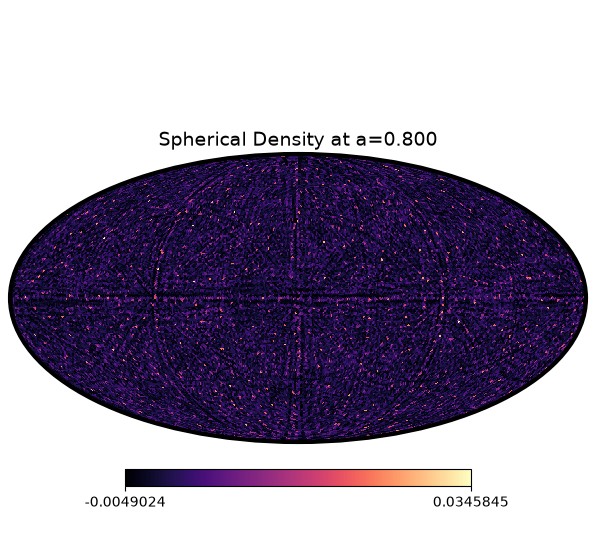

In [5]:
forward_model = jfli.ppl.make_full_field_model(config=config)

# Generate a mock observation (spin-2 shear: shape (n_bins, 2, npix))
observable_mock, lightcone_mock = jax.block_until_ready(forward_model(cosmo, init_field))

print(f"Mock shear shape: {observable_mock.shape}")
print(f"Mock lightcone shape: {lightcone_mock.shape}")
observable_mock.show(ncols=2)

## Build Probabilistic Model

`full_field_probmodel` wraps the forward model in a NumPyro model that:
1. Samples cosmological parameters from the priors
2. Samples the initial conditions from a standard normal
3. Runs the forward model
4. Adds Gaussian noise based on `sigma_e` and galaxy density

In [6]:
prob_model = jfli.ppl.full_field_probmodel(config)

In [7]:
model_trace = trace(seed(prob_model, 0)).get_trace()

omega_c = model_trace["Omega_c"]["value"]
sigma8 = model_trace["sigma8"]["value"]
init_field = model_trace["initial_conditions"]["value"]
# Observable sites are plain arrays (shear: (2, npix) per bin); the IC site is a DensityField.
observables = {f"observable_{i}": model_trace[f"observable_{i}"]["value"] for i in range(len(config.nz_shear))}

print("Sharding of init_field is")
jax.debug.visualize_array_sharding(init_field.array[..., 0])
print("Sharding of observable_0 (shear E/B x npix) is")
jax.debug.visualize_array_sharding(observables["observable_0"])

Sharding of init_field is


                         
                         
                         
                         
                         
          GPU 0          
                         
                         
                         
                         
                         

Sharding of observable_0 (shear E/B x npix) is


  GPU 0  
         

In [8]:
from jax_fli.io import Catalog

# Warm-start the IC at the truth as a plain array (the CLI-canonical form). The model wraps it back
# into a DensityField internally; passing the raw array keeps init_to_value's tree-map clean.
init_params = {"Omega_c": omega_c, "sigma8": sigma8, "initial_conditions": init_field.array}

# Condition on the mock observables (one per source bin — len(nz_shear), NOT number_of_shells).
conditioned_model = condition(
    prob_model,
    data={f"observable_{i}": model_trace[f"observable_{i}"]["value"] for i in range(len(config.nz_shear))},
)
print(f"Omega_c {omega_c} sigma8 {sigma8}")

cosmo = jc.Planck18(Omega_c=omega_c, sigma8=sigma8)
init_field = init_field.replace(z_sources=0.0, density_width=0.0, comoving_centers=0.0, scale_factors=0.0)
Catalog(field=init_field, cosmology=cosmo).to_parquet("truth.parquet")

Omega_c 0.1322497466657265 sigma8 0.8684771947276679


Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

## Sampling with batched_sampling

`batched_sampling` runs MCMC in checkpointed batches. Each batch is saved to disk, allowing long runs to be resumed. It builds the log-density from the NumPyro model and samples it with **BlackJAX**. It supports:
- **Sampler**: `"NUTS"` or `"MCLMC"`
- **Tuning**: NUTS knobs (`max_num_doublings`, `target_accept`) and MCLMC knobs (`mclmc_desired_energy_var`, `mclmc_init_step_size_scale`, ...)
- **Batching**: `batch_count` controls how many batches to run sequentially

For this demo we use a very small number of samples.

### Single device vs. multiple devices

As written this cell runs on **one device** (`mesh is None`). It works on CPU or a single GPU.

**Multiple devices must use multiple processes**, not the single-process fake-CPU mesh. If you uncomment `jax.config.update("jax_num_cpu_devices", 4)` in the setup cell to get a `(4, 1)` mesh in *one* process, NUTS **deadlocks** during warmup: BlackJAX's tree-building is a data-dependent `while_loop`, and the per-step `all-reduce` of the sharded log-density / energy scalars runs on XLA:CPU's *in-process* communicator, where a divergent collective order hangs the rendezvous ("expected 4 threads, only 3 arrived"). This is **not** the painting halo exchange — setting `halo_size=(0, 0)` does not help, the stuck op is the `AllReduceThunk`, not a `CollectivePermuteThunk`.

The robust multi-device path is genuine **multi-process** (one device per process; collectives go cross-process via gloo/NCCL, which stays in lockstep). Use the sibling script and launch it with MPI:

```bash
mpirun -n 4 --oversubscribe python 14_lpt_inference_mp.py   # local fake 4-CPU
```

It mirrors this notebook (same `Configurations`, `sim_mode="lpt"`) plus a `maybe_initialize_distributed()` (the `bin/fli-infer` pattern). On a GPU cluster drop `JAX_PLATFORMS=cpu` and launch one rank per GPU (srun/mpirun) — exactly how `fli-infer` runs distributed inference.

In [9]:
output_path = "output/demo_inference"
sample_key = jax.random.PRNGKey(0)

if mesh is not None:
    jax.set_mesh(mesh)

# num_samples > 1 so the posterior diagnostics below (ArviZ ESS / rank plots, GetDist triangle) have
# enough draws — ESS is undefined for a single draw. Still a tiny smoke run; bump these for real work.
jfli.infer.batched_sampling(
    conditioned_model,
    init_params=init_params,
    path=output_path,
    rng_key=sample_key,
    num_warmup=10,
    num_samples=50,
    batch_count=1,
    sampler=config.sampler,  # "NUTS"
    mclmc_desired_energy_var=config.mclmc_desired_energy_var,
    mclmc_init_step_size_scale=config.mclmc_init_step_size_scale,
    max_num_doublings=config.nuts_max_num_doublings,
    target_accept=config.nuts_target_accept,
    progress_bar=True,
    save_callback=jfli.infer.sample2catalog(config),
)

Tuning NUTS parameters (step size and inverse mass matrix) with 10 warmup steps...
  ==> max_num_doublings=2, target_accept=0.65


Running window adaptation


<div><progress max="10" value="10"></progress> 100.00% [10/10 00:00&lt;?]</div>

Sampling batch 1/1 using NUTS (blackjax)...
At sample batch 1, total samples so far: 0


<div><progress max="50" value="50"></progress> 100.00% [50/50 00:00&lt;?]</div>

Saving batch 1 samples and state...


Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

No observable samples found, skipping observable catalog saving.


In [10]:
result = jfli.io.extract_catalog(
    set_name="full-field demo",
    cosmo_keys=["Omega_c", "sigma8"],
    patterns=[f"{output_path}/samples"],
    field_statistic=True,
)
print(result)

CatalogExtract(
  name='full-field demo',
  cosmo={'Omega_c': f64[1,50], 'sigma8': f64[1,50]},
  mean_field=DensityField(
    array=f64[1,64,64,64],
    mesh_size=(64, 64, 64),
    box_size=(1408.597412109375, 1408.597412109375, 1408.597412109375),
    z_sources=np.float64(0.0),
    scale_factors=np.float64(0.0),
    comoving_centers=np.float64(0.0),
    density_width=np.float64(0.0),
    observer_position=(0.5, 0.5, 0.5),
    halo_size=(4, 4),
    nside=64,
    status=<FieldStatus.INITIAL_FIELD: '2'>,
    unit=<DensityUnit.DENSITY: '2'>,
    name=np.str_('initial_conditions_batch_0')
  ),
  std_field=DensityField(
    array=f64[1,64,64,64],
    mesh_size=(64, 64, 64),
    box_size=(1408.597412109375, 1408.597412109375, 1408.597412109375),
    z_sources=np.float64(0.0),
    scale_factors=np.float64(0.0),
    comoving_centers=np.float64(0.0),
    density_width=np.float64(0.0),
    observer_position=(0.5, 0.5, 0.5),
    halo_size=(4, 4),
    nside=64,
    status=<FieldStatus.INITIAL_FIEL

In [11]:
# Diagnostics (ArviZ rank/trace + summary.md, field projections) and the GetDist triangle plot.
jfli.infer.analyze(result, "output/demo_report")
jfli.infer.plot_posterior(
    result,
    outpath="output/demo_report/posterior.png",
    labels={"Omega_c": r"\Omega_c", "sigma8": r"\sigma_8"},
)

Removed no burn in
